In [50]:
from postseason_simulator.load_results import load_series
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
def generate_wide_simulation_df(input_df: pd.DataFrame, year_col_name: str = "year", sim_col_name: str = "simulation"):
    """
        Creates a wide dataframe with one row per simulation and champion by year in its own column.

        Assumes input_df only contains results from championship game
    """
    sim_results = []
    years = input_df[year_col_name].unique()
    num_simulations = input_df[sim_col_name].max()

    for simulation in range(1, num_simulations+1):
        sim_result = {}
        sim_result['simulation'] = simulation

        for year in years:
            sim_result[year] = input_df[(input_df['year'] == year) & (input_df['simulation'] == simulation)]['winner'].iloc[0]

        sim_results.append(sim_result)
        
    sim_results_df = pd.DataFrame(sim_results)

    return sim_results_df

In [159]:
def count_team_titles_in_sim(row, years: list[int], team_name: str):
    """
        Counts number of time team was the champ over the seasons designated in the years param
    """
    total_championships = 0
    for year in years:
        champ_in_year = 1 if row[year].strip().lower() == team_name.strip().lower() else 0
        total_championships += champ_in_year

    return total_championships

In [174]:
def plot_team_championships_distribution(input_df: pd.DataFrame, team_name: str, years: list[int], actual_championships: int = 0, title: str = None):
    """
        Plots distribution of expected championships for team_name over the input years. Plots the number of actual championships
        as a vertical line.

        input_df is expected to be in the wide_simulation_df format
    """
    team_name_titles_col_name = f'{team_name}_titles'
    input_df[team_name_titles_col_name] = input_df.apply(lambda row: count_team_titles_in_sim(row, years, team_name),axis=1)
    
    agg_df = input_df.groupby([team_name_titles_col_name])['simulation'].count().reset_index().rename(columns={'simulation':'count'})
    fig, ax = plt.subplots(figsize=(10, 6))
    # Numeric bars (not categorical)
    ax.bar(
        agg_df[team_name_titles_col_name],
        agg_df['count'],
        width=0.8
    )

    # Ensure axis includes 0 even if not present
    ax.set_xticks(range(
        min(0, agg_df[team_name_titles_col_name].min()),
        agg_df[team_name_titles_col_name].max() + 1
    ))
    ax.axvline(actual_championships, color='red', linestyle='--', linewidth=1.5, label=f'Actual Championships: {actual_championships}')
    
    ax.legend()
    ax.set_xlabel('National Championships')
    ax.set_ylabel('Count')
    if title is None:
        year_max = years.max()
        year_min = years.min()
        ax.set_title(f'Distribution of Simulated {team_name} Championships {year_min} - {year_max}')
    else:
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

In [54]:
def championship_rate_by_season(input_df, team_name: str, years: list[int]):
    """
        Aggregates pct. of times team was champion in simulation results per year in the input_df

        input_df is expected to be in a df with only championship game results
    """
    team_won_championship_col_name = f'{team_name}_won_championship'
    champ_rate_by_season_df = input_df.copy(deep=True)
    champ_rate_df = input_df.copy(deep=True)
    champ_rate_df[team_won_championship_col_name] = champ_rate_df.apply(lambda row: 1 if row['winner'] == team_name else 0,axis=1)

    return champ_rate_df.groupby('year')[team_won_championship_col_name].mean().reset_index().rename(columns={team_won_championship_col_name: 'Champion Rate'})
    

In [62]:
years = np.arange(2014,2024,1)

## BCS What-if?
What if the BCS was never replaced by the 4 team CFB playoff?

In [65]:
only_bcs_df = load_series("bcs_from_2014_2023")

In [66]:
only_bcs_df

,year,simulation,round,game,team_a,team_b,winner,home_team,is_championship
0,2014,1,0,0,Alabama,Oregon,Alabama,None,True
1,2014,10,0,0,Alabama,Oregon,Alabama,None,True
2,2014,100,0,0,Alabama,Oregon,Alabama,None,True
3,2014,1000,0,0,Alabama,Oregon,Alabama,None,True
4,2014,101,0,0,Alabama,Oregon,Alabama,None,True
...,...,...,...,...,...,...,...,...,...
9995,2023,995,0,0,Michigan,Washington,Michigan,None,True
9996,2023,996,0,0,Michigan,Washington,Michigan,None,True
9997,2023,997,0,0,Michigan,Washington,Michigan,None,True
9998,2023,998,0,0,Michigan,Washington,Michigan,None,True


In [67]:
only_bcs_champs_df = only_bcs_df[only_bcs_df['is_championship']] # only looking at championship game results

In [68]:
only_bcs_simulation_results_df = generate_wide_simulation_df(only_bcs_champs_df)

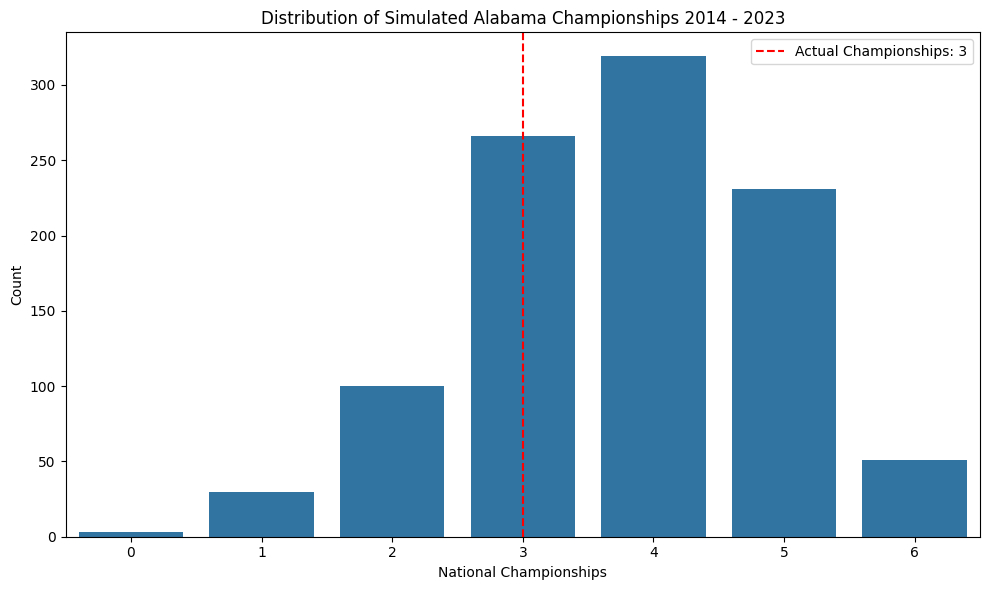

In [69]:
plot_team_championships_distribution(only_bcs_simulation_results_df, 'Alabama', years, 3)

In [70]:
championship_rate_by_season(only_bcs_champs_df, 'Alabama', years)

,year,Champion Rate
0,2014,0.750
1,2015,0.699
2,2016,0.572
3,2017,0.000
4,2018,0.666
5,2019,0.000
6,2020,0.542
7,2021,0.536
8,2022,0.000
9,2023,0.000


In [75]:
# what about teams other than Alabama?
for team_name in only_bcs_champs_df['winner'].unique():
    only_bcs_simulation_results_df[f"{team_name}_titles"] = only_bcs_simulation_results_df.apply(lambda row: count_team_titles_in_sim(row, years, team_name),axis=1)

In [80]:
title_cols = [x for x in only_bcs_simulation_results_df.columns.values if '_titles' in str(x)]

In [85]:
only_bcs_simulation_results_df[title_cols].mean().sort_values(ascending=False)

Alabama_titles       3.765
Clemson_titles       2.003
Michigan_titles      1.750
Ohio State_titles    0.572
Georgia_titles       0.568
Oklahoma_titles      0.518
LSU_titles           0.428
Oregon_titles        0.250
Washington_titles    0.146
dtype: float64

In [86]:
only_bcs_simulation_results_df[title_cols].median().sort_values(ascending=False)

Alabama_titles       4.0
Clemson_titles       2.0
Michigan_titles      2.0
Oklahoma_titles      1.0
Ohio State_titles    1.0
Georgia_titles       1.0
Oregon_titles        0.0
LSU_titles           0.0
Washington_titles    0.0
dtype: float64

In [87]:
championship_rate_by_season(only_bcs_champs_df, 'Michigan', years)

,year,Champion Rate
0,2014,0.000
1,2015,0.000
2,2016,0.000
3,2017,0.000
4,2018,0.000
5,2019,0.000
6,2020,0.000
7,2021,0.464
8,2022,0.432
9,2023,0.854


In [89]:
championship_rate_by_season(only_bcs_champs_df, 'Clemson', years)

,year,Champion Rate
0,2014,0.000
1,2015,0.301
2,2016,0.428
3,2017,0.482
4,2018,0.334
5,2019,0.000
6,2020,0.458
7,2021,0.000
8,2022,0.000
9,2023,0.000


# 12 Team College Football Playoff What-if?
What if the 12 team college football playoff was instituted directly after the BCS instead of the 4 team playoff?

In [92]:
cfp12_df = load_series("cfp12_from_2014_2023")
cfp12_champ_df = cfp12_df[cfp12_df['is_championship']]

In [93]:
cfp12_champ_df

,year,simulation,round,game,team_a,team_b,winner,home_team,is_championship
10,2014,1,3,0,Alabama,Baylor,Alabama,NaN,True
21,2014,10,3,0,Alabama,Baylor,Alabama,NaN,True
32,2014,100,3,0,Alabama,Baylor,Alabama,NaN,True
43,2014,1000,3,0,Oregon,Florida State,Florida State,NaN,True
54,2014,101,3,0,Oregon,Texas Christian,Oregon,NaN,True
...,...,...,...,...,...,...,...,...,...
109955,2023,995,3,0,Michigan,Georgia,Michigan,NaN,True
109966,2023,996,3,0,Michigan,Texas,Texas,NaN,True
109977,2023,997,3,0,Oregon,Texas,Oregon,NaN,True
109988,2023,998,3,0,Ohio State,Georgia,Georgia,NaN,True


In [94]:
cfp12_simulation_results_df = generate_wide_simulation_df(cfp12_champ_df)

In [96]:
cfp12_all_winners = cfp12_champ_df['winner'].unique()

In [98]:
print(f"Number of unique teams winning a championship: {len(cfp12_all_winners)}")

Number of unique teams winning a championship: 37


In [95]:
cfp12_simulation_results_df

,simulation,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,Alabama,Oklahoma,Ohio State,Penn State,Clemson,LSU,Ohio State,Georgia,Texas Christian,Ohio State
1,2,Florida State,Ole Miss,Ohio State,Oklahoma,Alabama,Oregon,Notre Dame,Alabama,Georgia,Georgia
2,3,Alabama,Ohio State,Alabama,Alabama,Georgia,Clemson,Clemson,Georgia,Michigan,Michigan
3,4,Ohio State,Ole Miss,Oklahoma,Georgia,Georgia,Ohio State,Alabama,Cincinnati,Michigan,Texas
4,5,Alabama,Alabama,Wisconsin,Auburn,Clemson,Ohio State,Oklahoma,Georgia,Ohio State,Michigan
...,...,...,...,...,...,...,...,...,...,...,...
995,996,Alabama,Ohio State,Alabama,Ohio State,Alabama,Georgia,Ohio State,Georgia,Georgia,Texas
996,997,Alabama,Michigan State,Florida State,Oklahoma,Alabama,LSU,Clemson,Georgia,Georgia,Oregon
997,998,Florida State,Alabama,Michigan,Alabama,Georgia,LSU,Ohio State,Alabama,Alabama,Georgia
998,999,Alabama,Oklahoma,Clemson,Alabama,Oklahoma,Ohio State,Clemson,Georgia,Michigan,Georgia


In [100]:
for team_name in cfp12_all_winners:
    cfp12_simulation_results_df[f"{team_name}_titles"] = cfp12_simulation_results_df.apply(lambda row: count_team_titles_in_sim(row, years, team_name),axis=1)

In [102]:
title_cols = [x for x in cfp12_simulation_results_df.columns.values if '_titles' in str(x)]

In [104]:
cfp12_simulation_results_df[title_cols].mean().sort_values(ascending=False)

Alabama_titles              2.428
Ohio State_titles           1.807
Georgia_titles              1.540
Clemson_titles              0.818
Michigan_titles             0.727
Oklahoma_titles             0.401
Florida State_titles        0.281
LSU_titles                  0.279
Washington_titles           0.235
Ole Miss_titles             0.208
Oregon_titles               0.170
Notre Dame_titles           0.145
Penn State_titles           0.124
Texas Christian_titles      0.098
Cincinnati_titles           0.089
Stanford_titles             0.085
Wisconsin_titles            0.084
Baylor_titles               0.081
Texas_titles                0.077
Auburn_titles               0.070
Florida_titles              0.048
Mississippi State_titles    0.044
Michigan State_titles       0.042
Tennessee_titles            0.032
Texas A&M_titles            0.021
USC_titles                  0.020
Pitt_titles                 0.011
Oklahoma State_titles       0.011
Utah_titles                 0.009
North Carolina

In [103]:
cfp12_simulation_results_df[title_cols].median().sort_values(ascending=False)

Alabama_titles              2.0
Ohio State_titles           2.0
Michigan_titles             1.0
Clemson_titles              1.0
Georgia_titles              1.0
Tennessee_titles            0.0
Pitt_titles                 0.0
Iowa State_titles           0.0
Indiana_titles              0.0
Texas A&M_titles            0.0
Wisconsin_titles            0.0
Utah_titles                 0.0
Kansas State_titles         0.0
Florida_titles              0.0
LSU_titles                  0.0
Miami_titles                0.0
Texas_titles                0.0
UCF_titles                  0.0
Auburn_titles               0.0
Cincinnati_titles           0.0
Oklahoma State_titles       0.0
Penn State_titles           0.0
Florida State_titles        0.0
Washington_titles           0.0
USC_titles                  0.0
Notre Dame_titles           0.0
North Carolina_titles       0.0
Stanford_titles             0.0
Oklahoma_titles             0.0
Georgia Tech_titles         0.0
Ole Miss_titles             0.0
Mississi

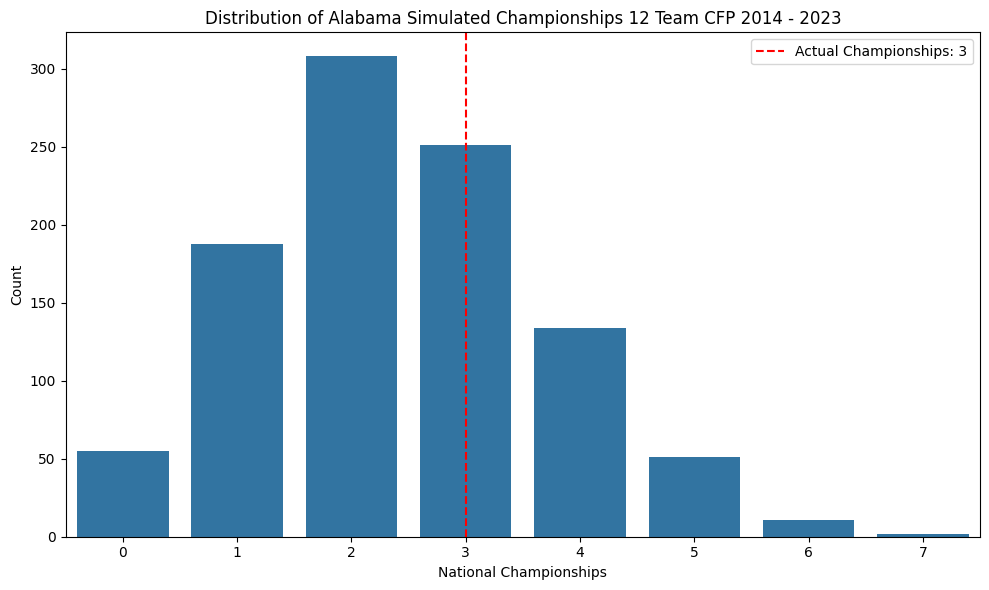

In [109]:
plot_team_championships_distribution(cfp12_simulation_results_df, 'Alabama', years, 3, title="Distribution of Alabama Simulated Championships 12 Team CFP 2014 - 2023")

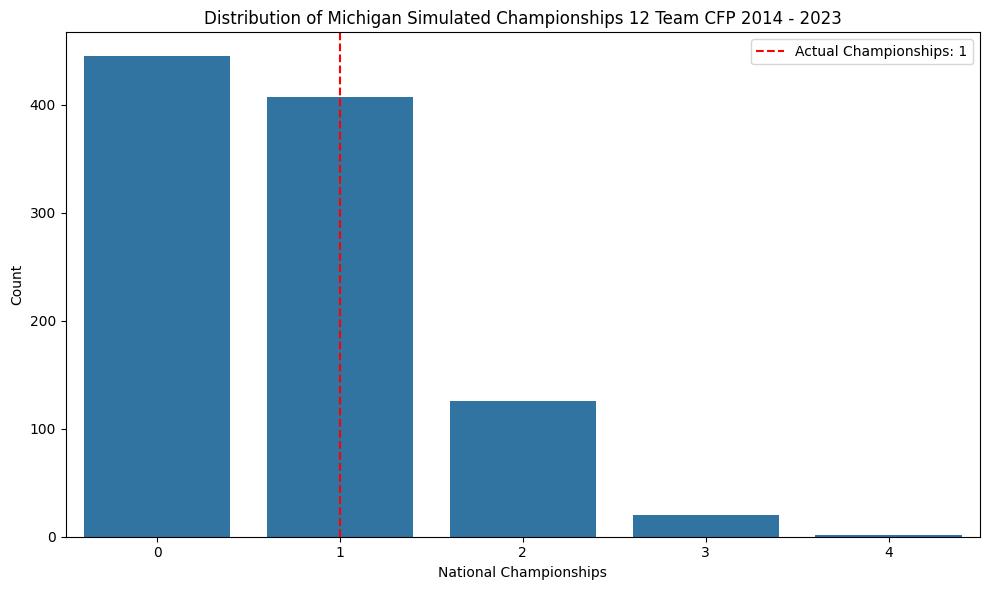

In [111]:
plot_team_championships_distribution(cfp12_simulation_results_df, 'Michigan', years, 1, title="Distribution of Michigan Simulated Championships 12 Team CFP 2014 - 2023")

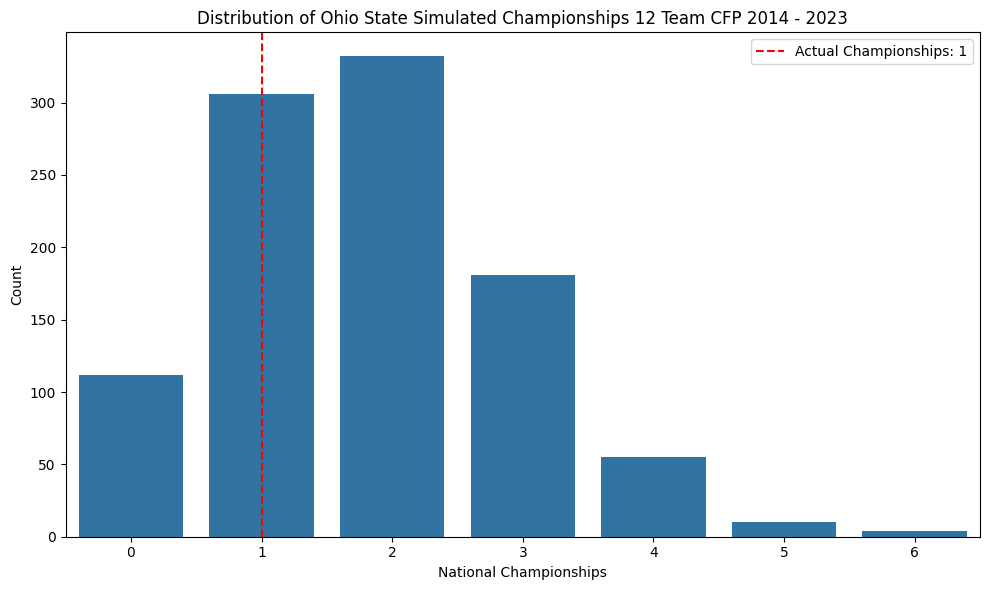

In [112]:
plot_team_championships_distribution(cfp12_simulation_results_df, 'Ohio State', years, 1, title="Distribution of Ohio State Simulated Championships 12 Team CFP 2014 - 2023")

In [113]:
championship_rate_by_season(cfp12_champ_df, 'Michigan', years)

,year,Champion Rate
0,2014,0.000
1,2015,0.000
2,2016,0.084
3,2017,0.000
4,2018,0.013
5,2019,0.000
6,2020,0.000
7,2021,0.135
8,2022,0.210
9,2023,0.285


In [114]:
championship_rate_by_season(cfp12_champ_df, 'Georgia', years)

,year,Champion Rate
0,2014,0.000
1,2015,0.000
2,2016,0.000
3,2017,0.090
4,2018,0.277
5,2019,0.086
6,2020,0.012
7,2021,0.360
8,2022,0.391
9,2023,0.324


In [115]:
championship_rate_by_season(cfp12_champ_df, 'Alabama', years)

,year,Champion Rate
0,2014,0.441
1,2015,0.196
2,2016,0.321
3,2017,0.330
4,2018,0.461
5,2019,0.000
6,2020,0.248
7,2021,0.198
8,2022,0.157
9,2023,0.076


In [116]:
championship_rate_by_season(cfp12_champ_df, 'Ohio State', years)

,year,Champion Rate
0,2014,0.103
1,2015,0.228
2,2016,0.050
3,2017,0.191
4,2018,0.035
5,2019,0.394
6,2020,0.365
7,2021,0.195
8,2022,0.159
9,2023,0.087


## Only 12 Team CFP What-If?
What if the 12 team CFP existed for Saban's whole tenure?

In [157]:
years = np.arange(2007,2024)

In [117]:
all_cfp12_df = load_series("cfp12_from_2007_2023")
all_cfp12_champ_df = all_cfp12_df[all_cfp12_df['is_championship']]

In [118]:
all_cfp12_simulation_results_df = generate_wide_simulation_df(all_cfp12_champ_df)

In [119]:
all_cfp12_simulation_results_df

,simulation,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,1,LSU,Florida,Alabama,Ohio State,Oklahoma State,Alabama,Florida State,Michigan State,Oklahoma,Washington,Alabama,Georgia,Ohio State,Ohio State,Michigan,Michigan,Michigan
1,2,Oklahoma,Alabama,Texas,LSU,Oklahoma State,Alabama,Alabama,Alabama,Oklahoma,Alabama,Oklahoma,Georgia,Ohio State,Clemson,Georgia,Georgia,Ole Miss
2,3,Kansas,Texas,Florida,Ohio State,LSU,Florida,Florida State,Alabama,Alabama,Washington,Alabama,Alabama,Clemson,Ohio State,Cincinnati,Tennessee,Georgia
3,4,Oklahoma,Oklahoma,Alabama,Auburn,Oklahoma State,Alabama,Ohio State,Oregon,Notre Dame,Washington,Wisconsin,Alabama,Ohio State,Notre Dame,Georgia,Michigan,Michigan
4,5,Oklahoma,Texas,Alabama,Stanford,Oklahoma State,Georgia,Florida State,Alabama,Ohio State,Alabama,Alabama,Clemson,Ohio State,Alabama,Georgia,Ohio State,Georgia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Oklahoma,Texas,Texas Christian,Ohio State,LSU,Oklahoma,Florida State,Alabama,Clemson,Washington,Ohio State,LSU,LSU,Alabama,Georgia,Michigan,Alabama
996,997,Oklahoma,Florida,Texas,Stanford,Oklahoma State,Alabama,Florida State,Ohio State,Alabama,Washington,Alabama,Georgia,Ohio State,Clemson,Alabama,Georgia,Michigan
997,998,Missouri,Florida,Alabama,Boise State,Alabama,Alabama,Florida State,Alabama,Notre Dame,Alabama,Alabama,Georgia,Clemson,Notre Dame,Cincinnati,Georgia,Oregon
998,999,USC,Texas,Florida,Ohio State,LSU,Alabama,Alabama,Alabama,Stanford,Clemson,Alabama,Alabama,Ohio State,Clemson,Georgia,Michigan,Georgia


In [120]:
all_cfp12_all_winners = all_cfp12_champ_df['winner'].unique()

In [160]:
for team_name in all_cfp12_all_winners:
    all_cfp12_simulation_results_df[f"{team_name}_titles"] = all_cfp12_simulation_results_df.apply(lambda row: count_team_titles_in_sim(row, years, team_name),axis=1)

In [161]:
title_cols = [x for x in all_cfp12_simulation_results_df.columns.values if '_titles' in str(x)]

In [162]:
all_cfp12_simulation_results_df[title_cols].mean().sort_values(ascending=False)

Alabama_titles              3.660
Ohio State_titles           2.293
Georgia_titles              1.615
Oklahoma_titles             0.904
Clemson_titles              0.883
Florida State_titles        0.864
Florida_titles              0.764
LSU_titles                  0.698
Michigan_titles             0.667
Oregon_titles               0.648
USC_titles                  0.633
Texas_titles                0.527
Stanford_titles             0.305
Washington_titles           0.248
Texas Christian_titles      0.235
Auburn_titles               0.218
Oklahoma State_titles       0.212
Ole Miss_titles             0.196
Notre Dame_titles           0.170
Wisconsin_titles            0.162
Penn State_titles           0.162
Arkansas_titles             0.144
Virginia Tech_titles        0.112
Cincinnati_titles           0.102
Boise State_titles          0.083
Texas A&M_titles            0.081
Michigan State_titles       0.079
Baylor_titles               0.073
Missouri_titles             0.048
West Virginia_

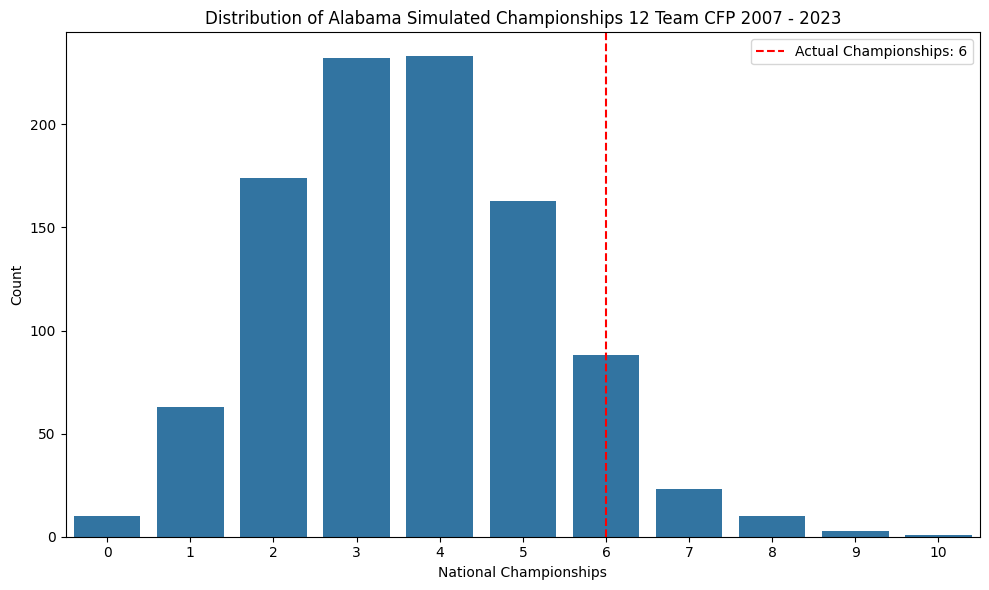

In [163]:
plot_team_championships_distribution(all_cfp12_simulation_results_df, 'Alabama', years, 6, title="Distribution of Alabama Simulated Championships 12 Team CFP 2007 - 2023")

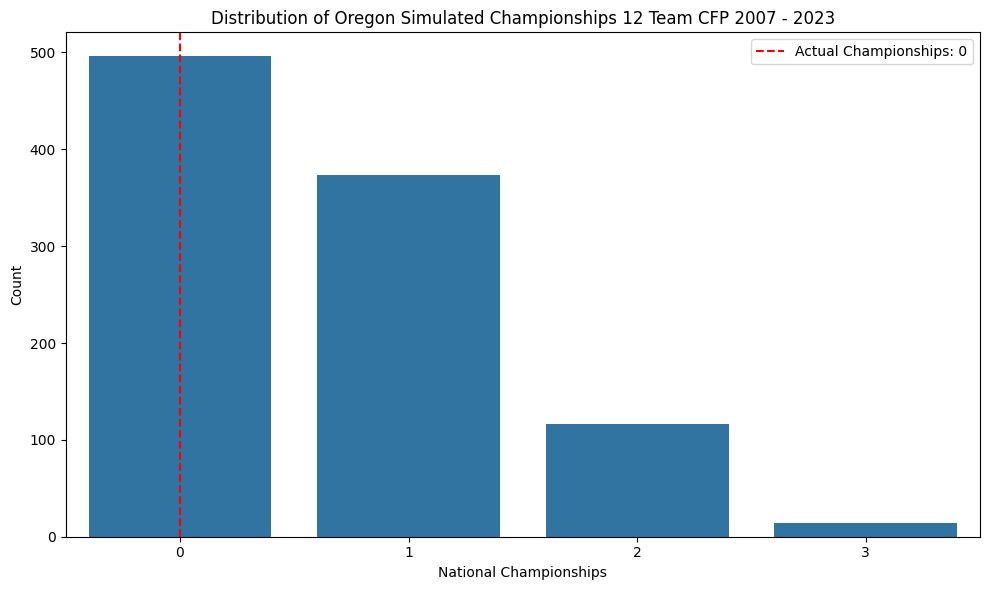

In [165]:
plot_team_championships_distribution(all_cfp12_simulation_results_df, 'Oregon', years, 0, title="Distribution of Oregon Simulated Championships 12 Team CFP 2007 - 2023")

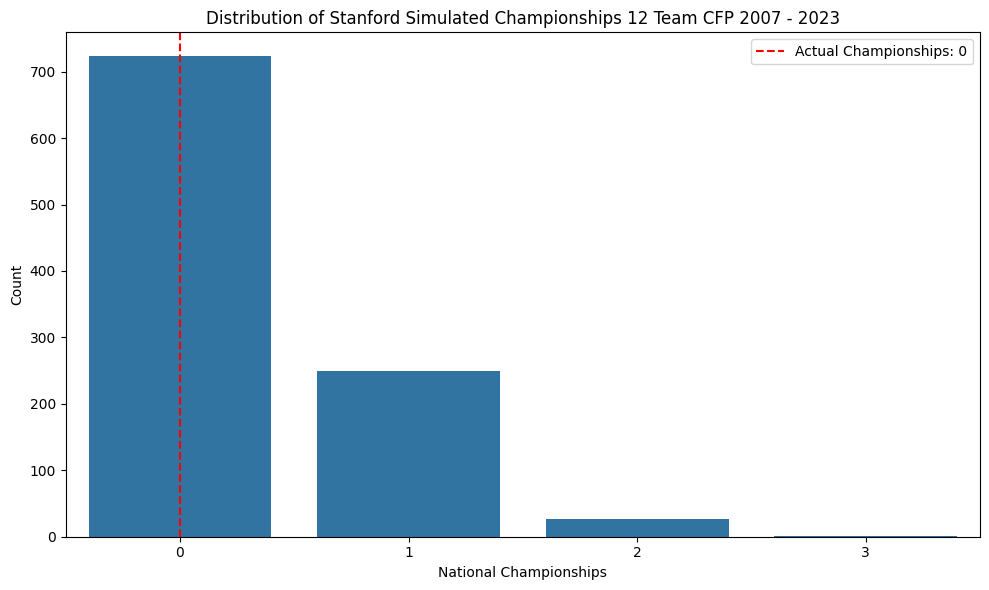

In [166]:
plot_team_championships_distribution(all_cfp12_simulation_results_df, 'Stanford', years, 0, title="Distribution of Stanford Simulated Championships 12 Team CFP 2007 - 2023")

In [167]:
championship_rate_by_season(all_cfp12_champ_df, 'Oregon', years)

,year,Champion Rate
0,2007,0.000
1,2008,0.000
2,2009,0.022
3,2010,0.175
4,2011,0.156
5,2012,0.099
6,2013,0.025
7,2014,0.073
8,2015,0.000
9,2016,0.000


## Only 4 Team CFP What-If?
What if the 4 team CFP existed for Saban's whole tenure?

In [197]:
all_cfp4_df = load_series("cfp4_from_2007_2023")
all_cfp4_champ_df = all_cfp4_df[all_cfp4_df['is_championship']]

# we know what happened from 2014-23
all_cfp4_champ_df = all_cfp4_champ_df[all_cfp4_champ_df['year'] < 2014]

In [201]:
years = np.arange(2007,2014)

In [202]:
all_cfp4_simulation_results_df = generate_wide_simulation_df(all_cfp4_champ_df)

In [203]:
all_cfp4_all_winners = all_cfp4_champ_df['winner'].unique()

In [204]:
for team_name in all_cfp4_all_winners:
    all_cfp4_simulation_results_df[f"{team_name}_titles"] = all_cfp4_simulation_results_df.apply(lambda row: count_team_titles_in_sim(row, years, team_name),axis=1)

In [205]:
title_cols = [x for x in all_cfp4_simulation_results_df.columns.values if '_titles' in str(x)]

In [206]:
all_cfp4_simulation_results_df[title_cols].mean().sort_values(ascending=False)

Alabama_titles            1.619
Texas_titles              0.893
LSU_titles                0.771
Oklahoma_titles           0.619
Florida State_titles      0.601
Oregon_titles             0.510
Florida_titles            0.448
Texas Christian_titles    0.359
Stanford_titles           0.323
Auburn_titles             0.252
Oklahoma State_titles     0.234
Ohio State_titles         0.219
Virginia Tech_titles      0.057
Notre Dame_titles         0.037
Cincinnati_titles         0.034
Michigan State_titles     0.024
dtype: float64

In [207]:
all_cfp4_simulation_results_df[title_cols].max().sort_values(ascending=False)

Alabama_titles            5
Oklahoma_titles           2
LSU_titles                2
Texas_titles              2
Florida_titles            2
Texas Christian_titles    2
Oregon_titles             2
Stanford_titles           2
Auburn_titles             2
Ohio State_titles         1
Virginia Tech_titles      1
Cincinnati_titles         1
Oklahoma State_titles     1
Notre Dame_titles         1
Florida State_titles      1
Michigan State_titles     1
dtype: int64

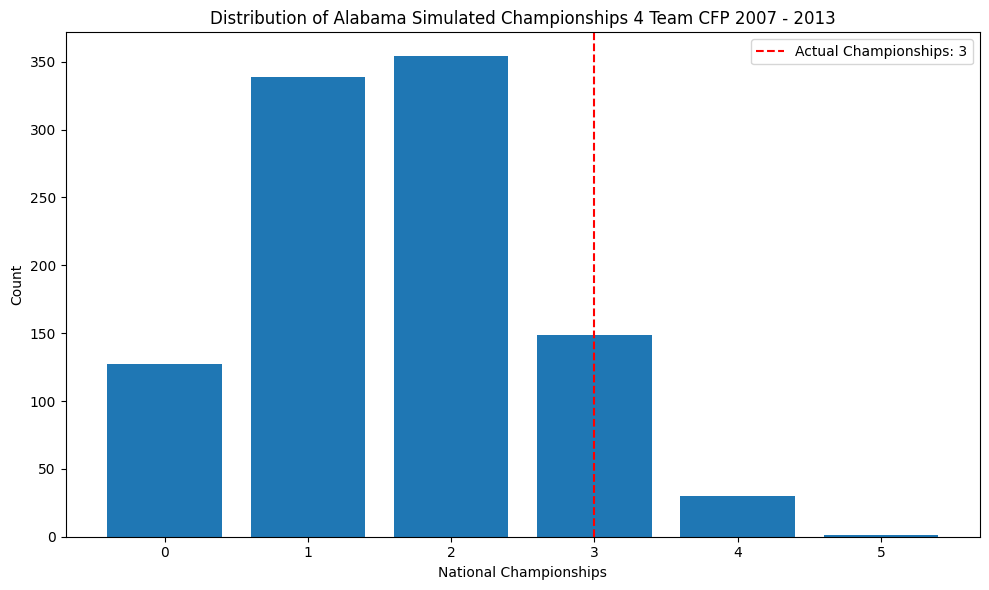

In [209]:
plot_team_championships_distribution(all_cfp4_simulation_results_df, 'Alabama', years, 3, title="Distribution of Alabama Simulated Championships 4 Team CFP 2007 - 2013")

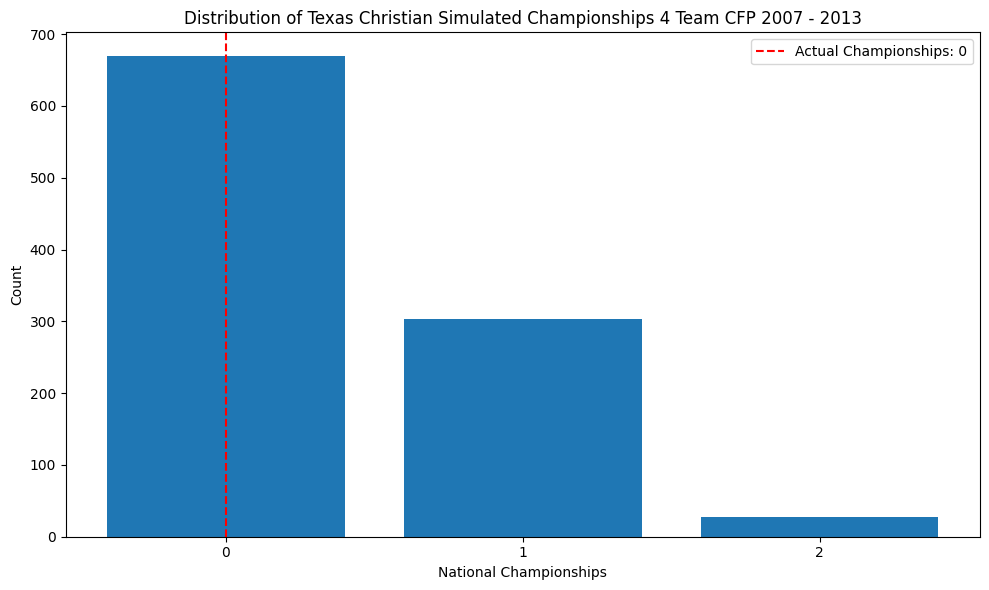

In [210]:
plot_team_championships_distribution(all_cfp4_simulation_results_df, 'Texas Christian', years, 0, title="Distribution of Texas Christian Simulated Championships 4 Team CFP 2007 - 2013")

## Putting it all together
What was the best postseason configuration to maximize the number of Nick Saban National Championships

In [211]:
saban_df = pd.DataFrame(
    [
        {
            "name":"BCS 2007-23",
            "expected_championships": 7
        },
        {
            "name": "4 Team CFP 2007-23",
            "expected_championships": 5
        },
        {
            "name": "BCS 2007-13, 4 Team CFP 2014-23 (reality)",
            "expected_championships": 6
        },
        {
            "name": "BCS 2007-13, 12 Team CFP 2014-23",
            "expected_championships": 5
        },
        {
            "name": "12 Team CFP 2007-23",
            "expected_championships": 5
        }
    ]
)

In [212]:
saban_df.sort_values('expected_championships',ascending=False)

,name,expected_championships
0,BCS 2007-23,7
2,"BCS 2007-13, 4 Team CFP 2014-23 (reality)",6
1,4 Team CFP 2007-23,5
3,"BCS 2007-13, 12 Team CFP 2014-23",5
4,12 Team CFP 2007-23,5


In [213]:
def highlight_row_based_on_value(row):
    if row["name"] == "BCS 2007-13, 4 Team CFP 2014-23 (reality)":
        return ["background-color: #d7be69"] * len(row)
    else:
        return [""] * len(row)

styled_df = saban_df.style.apply(highlight_row_based_on_value, axis=1)
styled_df

,name,expected_championships
0,BCS 2007-23,7
1,4 Team CFP 2007-23,5
2,"BCS 2007-13, 4 Team CFP 2014-23 (reality)",6
3,"BCS 2007-13, 12 Team CFP 2014-23",5
4,12 Team CFP 2007-23,5


In [214]:
bcs_rates = championship_rate_by_season(only_bcs_champs_df, 'Alabama', years)
cfp12_rates = championship_rate_by_season(cfp12_champ_df, 'Alabama', years)
all_cfp12_rates = championship_rate_by_season(all_cfp12_champ_df, 'Alabama', years)
all_cfp4_rates = championship_rate_by_season(all_cfp4_champ_df, 'Alabama', years)

In [221]:
# only considering hypotheticals and not circumstances that occurred i.e. 4 team CFP in 2015
merged_championship_rates = (
    all_cfp4_rates
        .rename(columns={'Champion Rate': '4 Team CFP 2007-13'})
        .merge(
            all_cfp12_rates.rename(columns={'Champion Rate': '12 Team CFP 2007-23'}),
            on='year',
            how='outer'
        )
        .merge(
            bcs_rates.rename(columns={'Champion Rate': 'BCS 2007-23'}),
            on='year',
            how='outer'
        )
)

In [226]:
merged_championship_rates = merged_championship_rates.set_index("year")

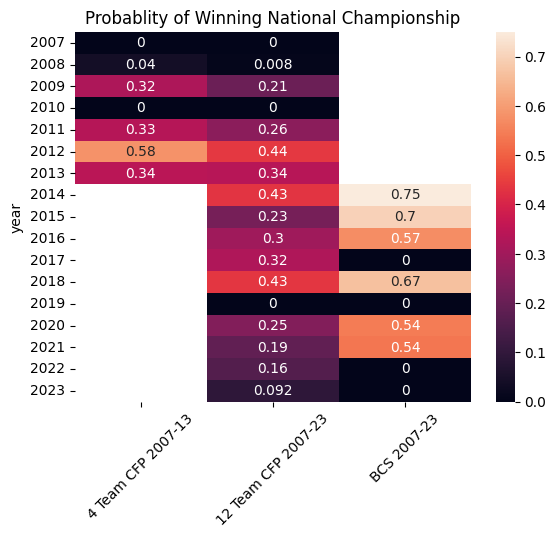

In [233]:
sns.heatmap(merged_championship_rates,annot=True)
plt.xticks(rotation=45)
plt.title("Probablity of Winning National Championship")
plt.show()